# ReadmitIQ · Who is eligible for discharge outreach, and what signals deserve testing?

**Phase 2: cohort definition, business-driven EDA and evaluation design.**
This notebook executes the reusable analysis against the checksum-verified UCI release.
It retains raw data, examines associations and proposes Phase 3 work. No models,
learned preprocessing or data partitions are created.

The unit of analysis is an eligible **encounter**, with dependence handled by patient.
The intended score is produced at completed discharge, after the destination is confirmed.
The outcome is the recorded `<30` label, not proven preventable or unplanned readmission.

Rate bars use 95% normal patient-cluster intervals, retaining within-patient dependence.
Intervals are suppressed for fewer than 30 patients, 10 events or 10 non-events.
They do not address confounding, missing follow-up, cohort selection or multiple comparisons.
We use a small set of practical contrasts, not significance hunting. Fixed display bins
are descriptive and are not learned modeling cutoffs.

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

from readmit_iq.analysis.run_phase2 import main
from readmit_iq.config import load_config
from readmit_iq.data.load_data import load_id_mapping

ROOT = Path.cwd()
if not (ROOT / 'configs/config.yaml').exists():
    ROOT = ROOT.parent
assert (ROOT / 'configs/config.yaml').exists()
import os
os.chdir(ROOT)
main()  # Recheck Phase 1, rebuild the cohort, tables, audits and all seven figures.
OUT = ROOT / 'reports/eda'
FIG = ROOT / 'reports/figures/eda'
summary = json.loads((OUT / 'summary.json').read_text())
assert summary['phase1_reconciled'] and summary['models_trained'] == 0
assert summary['partitions_created'] is False


def table(name, **kwargs):
    # The literal lab category None must not be parsed as a missing value.
    return pd.read_csv(OUT / f'{name}.csv', keep_default_na=False, na_values=[''], **kwargs)


rates = table('grouped_rates', dtype={'level': 'string'})
mappings = load_id_mapping(load_config().raw_dir / 'IDS_mapping.csv')


def show_rates(features):
    view = rates.loc[rates.feature.isin(features), [
        'feature', 'level', 'encounters', 'patients', 'positives', 'rate',
        'ci_low', 'ci_high', 'sparse'
    ]].copy()
    for column in ['rate', 'ci_low', 'ci_high']:
        view[column] = view[column].mul(100)
    view = view.rename(columns={'rate': 'rate_pct', 'ci_low': 'ci_low_pct', 'ci_high': 'ci_high_pct'})
    display(view.round(2).reset_index(drop=True))


def show_figure(name, width=1000):
    display(Image(filename=str(FIG / f'{name}.png'), width=width))


def show_contrasts(names):
    view = pd.DataFrame({name: summary['contrasts'][name] for name in names}).T
    display(view[['high_n', 'low_n', 'difference_pp', 'difference_ci_low_pp',
                  'difference_ci_high_pp', 'rate_ratio']].astype(float).round(3))


pd.set_option('display.max_rows', 40)
pd.set_option('display.max_columns', 12)
pd.set_option('display.width', 140)
display(pd.DataFrame({'raw': summary['raw'], 'eligible': summary['primary']}).T.round(4))

2026-09-22 09:35:18,553 INFO readmit_iq.data.load_data: Loaded diabetic_data.csv: 101766 rows, 50 columns


2026-09-22 09:35:25,519 INFO readmit_iq.analysis.run_phase2: Computed feature rates with patient-cluster uncertainty


2026-09-22 09:35:28,449 INFO readmit_iq.analysis.run_phase2: Phase 2 outputs: 90702 eligible encounters, 11.0847% positive, 7 figures


,encounters,patients,positives,negatives,prevalence_pct
raw,101766.0,71518.0,11357.0,90409.0,11.1599
eligible,90702.0,65044.0,10054.0,80648.0,11.0847


## 1 · Define the population before interpreting the label

### Question

Which encounters represent a completed discharge suitable for the proposed outreach workflow?

### Analysis

Apply outcome-independent disposition rules from `configs/phase2.yaml`. Compare the primary policy with plausible alternatives; validate all original labels before exclusion.

,reason,codes,encounters,positives
0,death,"11, 19, 20, 21",1652,0
1,hospice,"13, 14",771,43
2,inpatient_transfer,"2, 5, 10, 23, 27, 28, 29",3874,670
3,discharge_not_confirmed,"9, 12, 15",87,39
4,unknown_destination,"18, 25, 26, 30",4680,551


,stage,removed_at_stage,encounters,patients,positives,negatives,prevalence_pct
0,Raw source,0,101766,71518,11357,90409,11.160
1,After death,1652,100114,70439,11357,88757,11.344
2,After hospice,771,99343,69990,11314,88029,11.389
3,After inpatient_transfer,3874,95469,67785,10644,84825,11.149
4,After discharge_not_confirmed,87,95382,67749,10605,84777,11.118
5,After unknown_destination,4680,90702,65044,10054,80648,11.085


,cohort,encounters,patients,positives,negatives,prevalence_pct
0,Raw source,101766,71518,11357,90409,11.160
1,Exclude death/hospice only,99343,69990,11314,88029,11.389
2,Primary cohort,90702,65044,10054,80648,11.085
3,Primary + unknown destinations,95382,67749,10605,84777,11.118
4,Primary without mixed rehabilitation,88709,63998,9502,79207,10.711
5,Community destinations only,73892,55284,7345,66547,9.940


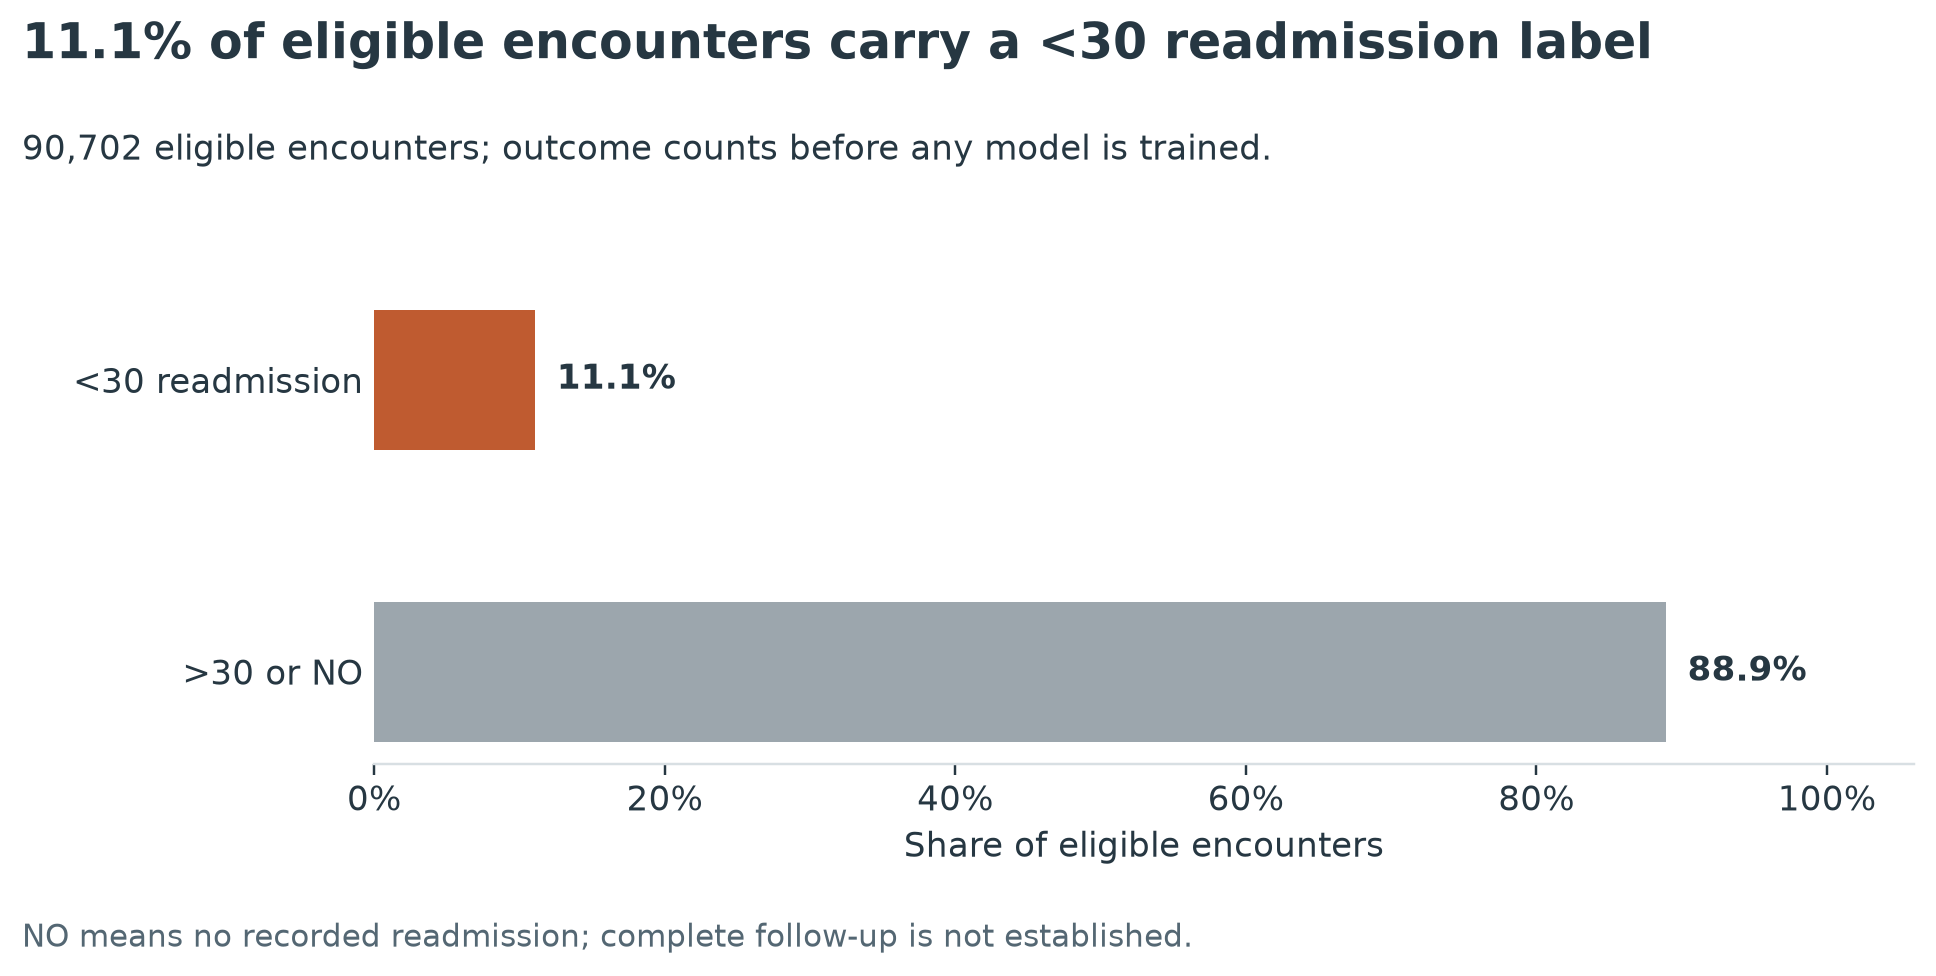

In [2]:
display(table('exclusions')[['reason', 'codes', 'encounters', 'positives']])
display(table('cohort_flow').round(3))
display(table('cohort_sensitivity').round(3))
show_figure('01_target_prevalence')

### Finding

The raw release has **101,766 encounters / 71,518 patients**. The primary cohort has
**90,702 encounters / 65,044 patients**, including **10,054 positives and 80,648 negatives (11.0847%)**.
The raw positive rate was 11.1599%; excluding only death/hospice would produce 11.3888%.

We remove 1,652 death-coded encounters (not live-discharge outreach), 771 hospice encounters
(a different care-goal pathway, not impossible readmission), 3,874 continued inpatient transfers,
87 encounters without confirmed discharge, and 4,680 unknown/insufficiently specified destinations.
Hospice contains 43 positive labels. All 30 source disposition codes and reasons are documented
in [the cohort report](../reports/data_quality/cohort_report.md).

Selected postacute settings remain eligible for coordinated follow-up. Rehabilitation code 22
mixes facilities and hospital units: removing it yields 88,709 encounters and 10.7114% prevalence.
Retaining unknown destinations yields 95,382 encounters and 11.1184%. These are workflow
sensitivities, not comparisons of model quality.

### Modeling implication

The target is `<30=1`, `>30/NO=0`, preserving the original field. It approximates the business
question; exact day 30, complete follow-up, planned readmissions and avoidability cannot be verified.
Finalize the mixed-rehabilitation and unknown-destination policy before splitting. Do not rebalance
or resample the evaluation population. No clinical intervention benefit is established.

## 2 · Repeated patients determine the validation design

### Question

How much of the cohort comes from repeat patients, and what would an encounter-level split leak?

### Analysis

Count eligible encounters per patient; compare encounter rates. Calculate expected identity overlap under hypothetical independent 70/15/15 encounter assignment. No split is created.

In [3]:
display(Markdown('**Raw patient distribution**'))
display(table('raw_repeat_patient_counts'))
display(Markdown('**Eligible patient distribution and encounter rates**'))
display(table('repeat_patient_counts'))
repeat_rates = table('repeat_patient_rates')
display(repeat_rates[['level', 'encounters', 'patients', 'positives', 'rate', 'ci_low', 'ci_high']].round(4))
display(pd.Series(summary['repeat_patients']['hypothetical_encounter_split']))

**Raw patient distribution**

,bucket,patients,encounters
0,1,54745,54745
1,2,10434,20868
2,3,3328,9984
3,4+,3011,16169


**Eligible patient distribution and encounter rates**

,bucket,patients,encounters
0,1,50481,50481
1,2,9238,18476
2,3,2868,8604
3,4+,2457,13141


,level,encounters,patients,positives,rate,ci_low,ci_high
0,Repeated,40221,14563,7846,0.1951,0.1907,0.1995
1,Single,50481,50481,2208,0.0437,0.0420,0.0455


expected_patients_in_multiple_partitions                                                  8180.070729
test_encounter_probability_patient_also_in_train                                             0.372068
assumption                                          Independent 70/15/15 encounter assignment; no ...
limitation                                           Estimates identity overlap, not metric inflation
dtype: object

### Finding

Eligible patients with 1 / 2 / 3 / 4+ encounters number **50,481 / 9,238 / 2,868 / 2,457**.
The 14,563 repeat patients account for **40,221 encounters (44.34%)**; the maximum is 39.
Their observed encounter readmission rate is **19.51%**, versus **4.37%** among single-encounter patients.
The raw cohort has 16,773 repeat patients contributing 46.21% of encounters.

An independent encounter-level allocation would put about **8,180 patients across partitions**.
A test encounter would have a **37.21%** chance of sharing its patient with training.
This quantifies identity overlap, not the size of resulting metric inflation.

### Modeling implication

Use 70/15/15 **patient-level** allocation, seed 42, approximately stratifying by any positive
encounter and encounter-count bucket. All encounters follow their patient. These aggregates are
allocation-only metadata: full-dataset repeat status uses future information and is forbidden
as a predictor. Lack of dates prevents temporal validation. See the [split design](../reports/modeling/split_strategy.md).

## 3 · Missingness is a data property, not a fill-in exercise

### Question

Which fields have enough coverage to be useful, and is unknown status associated with the outcome?

### Analysis

Distinguish literal `?`, administrative unknown codes, invalid gender and lab `None` (not measured). Compare unknown versus observed rates with patient-cluster uncertainty.

,variable,raw_question_marks,raw_unknown_pct,cohort_unknown_count,cohort_unknown_pct
0,weight,98569,96.858,87689,96.678
1,medical_specialty,49949,49.082,43794,48.283
2,payer_code,40256,39.557,33090,36.482
3,admission_type_id,0,10.216,8671,9.560
4,admission_source_id,0,6.944,6149,6.779
5,race,2273,2.234,2085,2.299
6,diag_3,1423,1.398,1307,1.441
7,diag_2,358,0.352,334,0.368
8,diag_1,21,0.021,15,0.017
9,gender,0,0.003,3,0.003


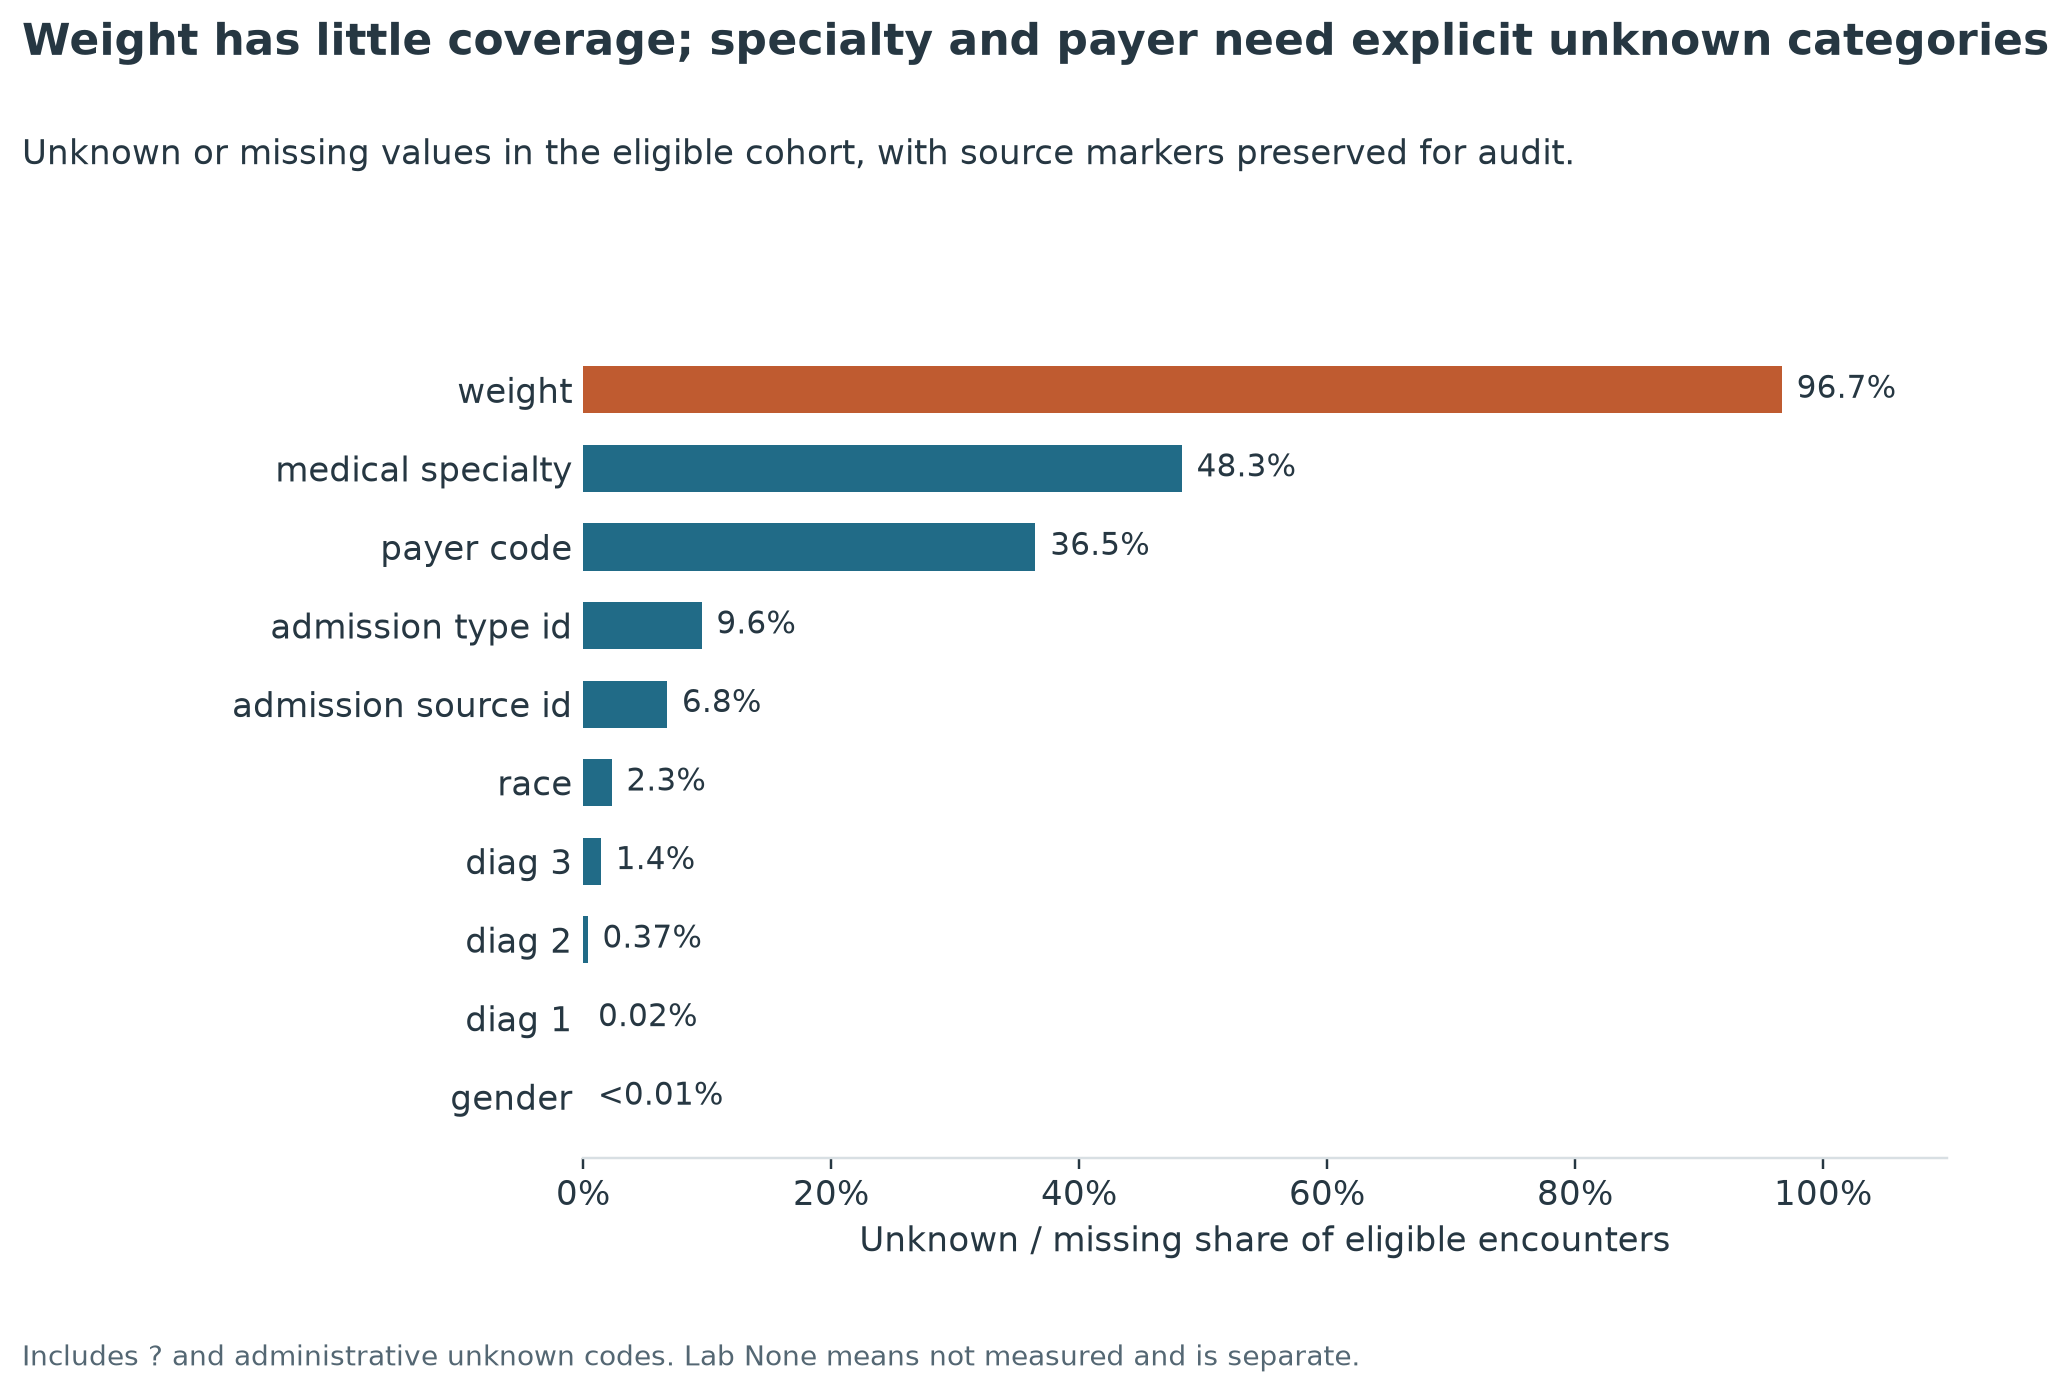

,high_n,low_n,high_rate,low_rate,difference_pp,difference_ci_low_pp,difference_ci_high_pp
weight,87689.0,3013.0,0.1108,0.1112,-0.0350,-1.2201,1.1501
medical_specialty,43794.0,46908.0,0.1152,0.1067,0.8503,0.3770,1.3236
payer_code,33090.0,57612.0,0.1115,0.1105,0.1051,-0.3824,0.5926
race,2085.0,88617.0,0.0796,0.1116,-3.1965,-4.4617,-1.9313


In [4]:
ranked = table('ranked_missingness')
display(ranked[['variable', 'raw_question_marks', 'raw_unknown_pct', 'cohort_unknown_count', 'cohort_unknown_pct']].round(3))
show_figure('07_missingness')
contrasts = pd.DataFrame(summary['missingness_contrasts']).T
selected = ['weight', 'medical_specialty', 'payer_code', 'race']
display(contrasts.loc[selected, ['high_n', 'low_n', 'high_rate', 'low_rate', 'difference_pp',
                               'difference_ci_low_pp', 'difference_ci_high_pp']].astype(float).round(4))

### Finding

Weight is unknown for **96.68%** of eligible encounters: only **3,013** observations remain.
Unknown versus observed weight rates are 11.08% and 11.12%; the difference is −0.04 percentage points
(95% interval −1.22 to 1.15). This does not prove observed weight has no predictive information,
but its coverage makes it a low-priority initial feature.

Medical specialty is unknown for **48.28%**, payer for **36.48%**, and race for **2.30%**.
Specialty unknown status has a modest +0.85 pp difference (0.38 to 1.32); payer +0.11 pp
(−0.38 to 0.59). Race unknown is associated with a lower recorded rate (−3.20 pp),
which may reflect documentation or population differences. Three gender values are invalid.
Missing primary diagnosis has only 15 encounters; do not overinterpret sparse differences.

### Modeling implication

Initially omit weight while preserving it for sensitivity. Retain explicit Unknown categories
for specialty/payer, document administrative mappings and preserve lab Not measured separately.
Do not infer MCAR/MAR/MNAR, causality, race or gender from these associations. Fit any encoding,
rare-category grouping and imputation on training only; no mean/mode filling now.
See the [missingness strategy](../reports/data_quality/missingness_strategy.md).

## 4 · Prior utilization contains different signals

### Question

Does readmission rise with prior use, is the relationship monotonic, and should counts be combined?

### Analysis

Compare source-defined prior-year inpatient, emergency and outpatient counts in 0/1/2/3+ bands. Inspect exact-count groups and pairwise rank correlations as a check on the plot simplification.

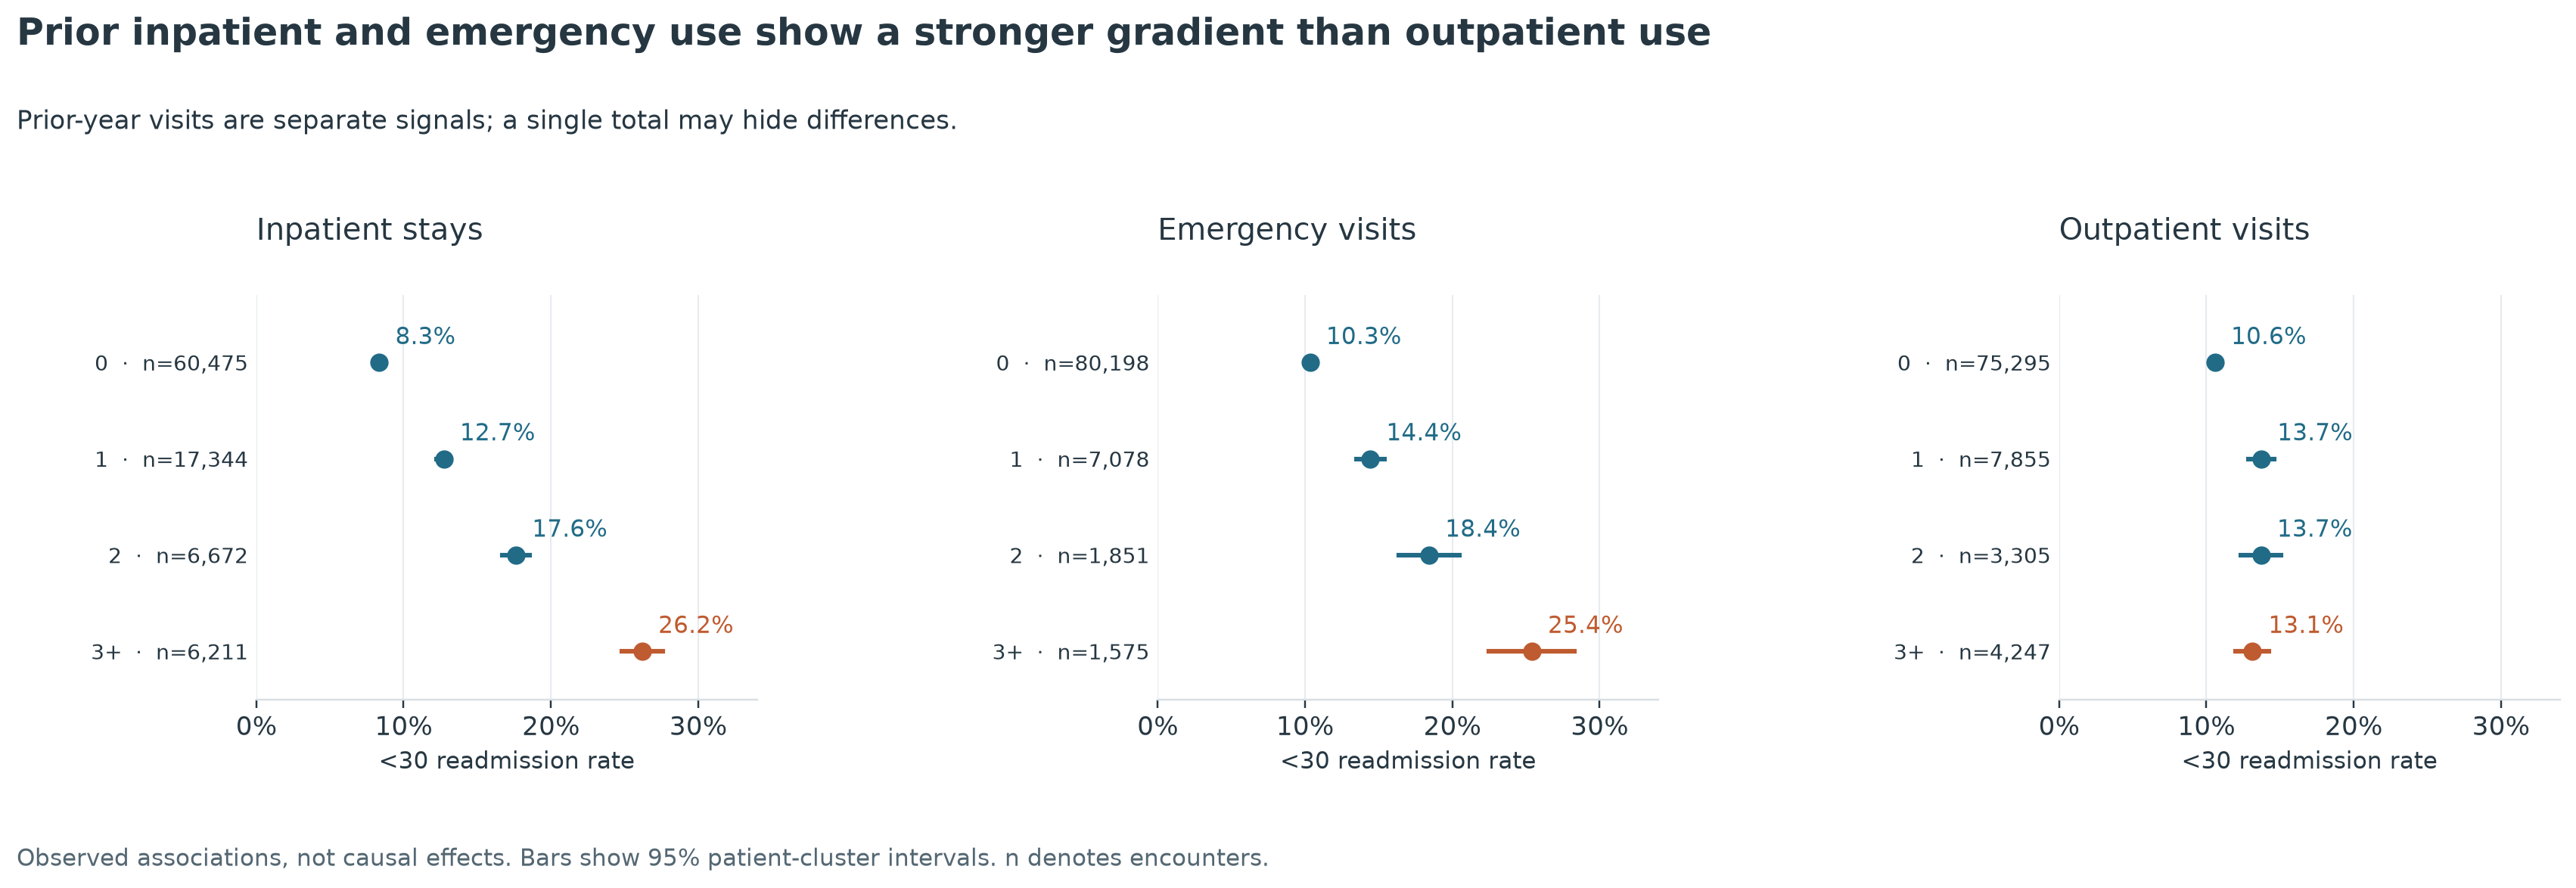

,high_n,low_n,difference_pp,difference_ci_low_pp,difference_ci_high_pp,rate_ratio
prior_inpatient_3plus_vs_0,6211.0,60475.0,17.855,16.445,19.265,3.141
prior_emergency_3plus_vs_0,1575.0,80198.0,15.057,12.153,17.962,2.456
outpatient_3plus_vs_1,4247.0,7855.0,-0.609,-2.016,0.799,0.956


,feature,number_inpatient,number_emergency,number_outpatient
0,number_inpatient,1.000,0.226,0.156
1,number_emergency,0.226,1.000,0.176
2,number_outpatient,0.156,0.176,1.000


,support_rule,monotonic_increasing_observed_rate,maximum_supported_count,interpretation
number_inpatient,Exact-count categories with at least 100 encou...,False,9,Descriptive shape only; no fitted monotonic co...
number_emergency,Exact-count categories with at least 100 encou...,False,5,Descriptive shape only; no fitted monotonic co...
number_outpatient,Exact-count categories with at least 100 encou...,False,7,Descriptive shape only; no fitted monotonic co...


,feature,count,encounters,rate
0,number_inpatient,0,60475,0.0834
1,number_inpatient,1,17344,0.1272
2,number_inpatient,2,6672,0.1763
3,number_inpatient,3,2956,0.2047
4,number_inpatient,4,1420,0.2451
5,number_inpatient,5,733,0.3179
6,number_inpatient,6,440,0.3409
7,number_inpatient,7,247,0.3482
8,number_inpatient,8,132,0.4621
9,number_inpatient,9,102,0.4216


In [5]:
show_figure('02_prior_utilization', width=1200)
show_contrasts(['prior_inpatient_3plus_vs_0', 'prior_emergency_3plus_vs_0', 'outpatient_3plus_vs_1'])
display(table('utilization_spearman').round(3))
display(pd.DataFrame(summary['utilization_shapes']).T)
exact = table('utilization_exact_rates')
display(exact.loc[exact.encounters.ge(100), ['feature', 'count', 'encounters', 'rate']].round(4).reset_index(drop=True))

### Finding

Inpatient rates rise **8.34% → 12.72% → 17.63% → 26.20%** across 0/1/2/3+ prior visits.
The 3+ versus zero difference is **17.85 pp** (95% interval **16.44–19.27**), a rate ratio of 3.14.
Emergency rates rise **10.34% → 14.42% → 18.42% → 25.40%**; the corresponding difference is
15.06 pp (12.15–17.96).

Outpatient rates are **10.58%, 13.72%, 13.71%, 13.12%**: no sustained increasing gradient.
The 3+ versus one-visit difference is −0.61 pp (−2.02 to 0.80), not clear evidence of a decline.
All three measures fluctuate at some exact counts even when restricting to groups with at least
100 encounters. For example, inpatient counts 8 and 9 have 46.21% and 42.16% rates but only
132 and 102 encounters. Pairwise Spearman correlations are only **0.156–0.226**.

### Modeling implication

Keep the three utilization counts separate. Test any-prior indicators and flexible numeric
representations before considering a supplementary total. Do not force monotonicity or replace
separate counts with an equal-weight total on this evidence. Use these prior-year fields,
not history reconstructed from undated future rows.

## 5 · The encounter contains burden signals, not clean causal explanations

### Question

How do stay length, medication count, laboratory work, procedures and diagnosis count relate to the outcome?

### Analysis

Compare grouped rates and target-specific distributions. Use a small set of interpretable contrasts; distinguish nonlinear plateaus from noisy tails.

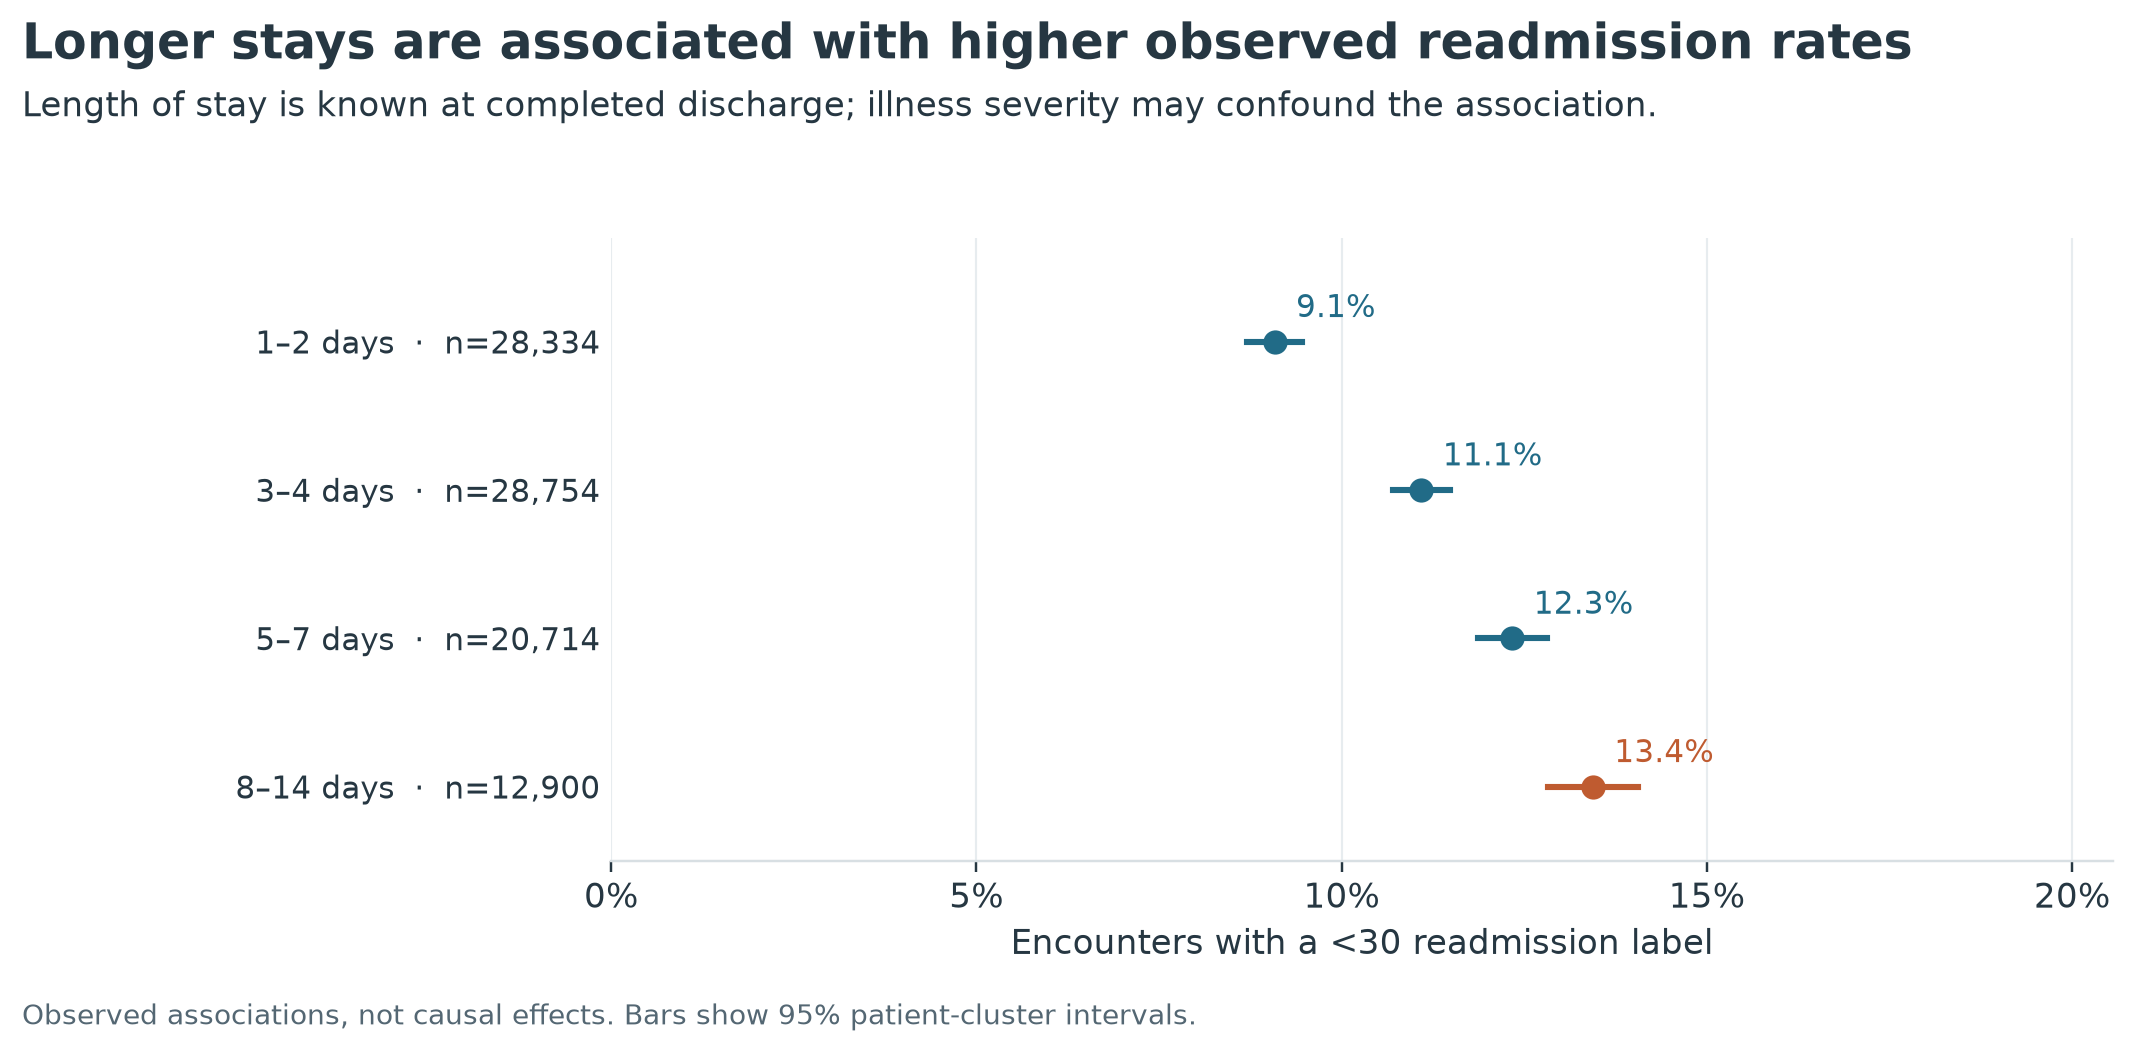

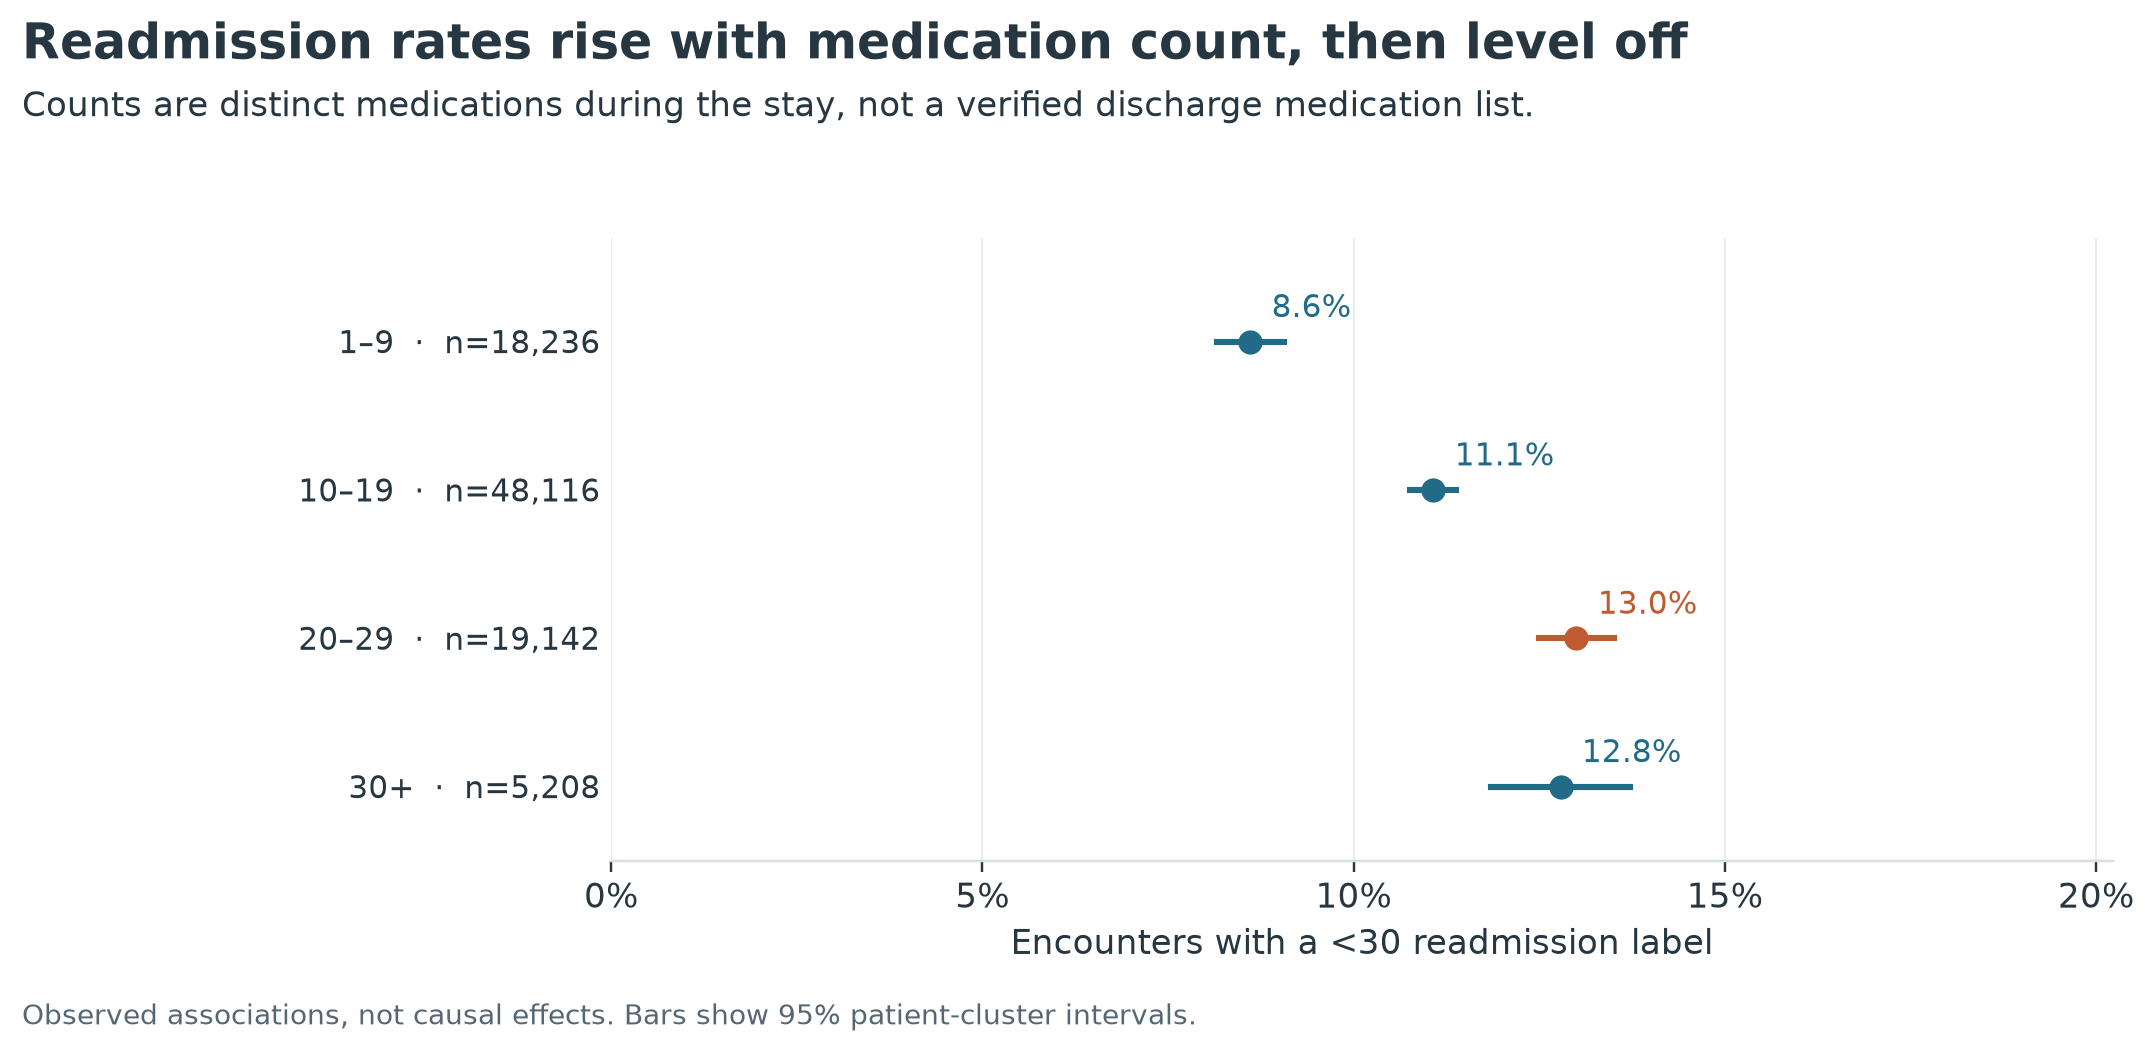

,high_n,low_n,difference_pp,difference_ci_low_pp,difference_ci_high_pp,rate_ratio
stay_8to14_vs_1to2,12900.0,28334.0,4.357,3.650,5.065,1.480
medications_20to29_vs_1to9,19142.0,18236.0,4.393,3.723,5.064,1.510
medications_30plus_vs_20to29,5208.0,19142.0,-0.215,-1.246,0.817,0.983


,feature,level,encounters,patients,positives,rate_pct,ci_low_pct,ci_high_pct,sparse
0,num_lab_procedures,1–20,13332,11761,1306,9.80,9.25,10.34,False
1,num_lab_procedures,21–40,24845,21499,2572,10.35,9.95,10.75,False
2,num_lab_procedures,41–60,35394,29072,4108,11.61,11.24,11.97,False
3,num_lab_procedures,61–80,15497,13778,1852,11.95,11.42,12.48,False
4,num_lab_procedures,81+,1634,1601,216,13.22,11.56,14.87,False
5,num_procedures,0,41746,32484,4560,10.92,10.58,11.26,False
6,num_procedures,1,18654,16406,2265,12.14,11.63,12.65,False
7,num_procedures,2,11355,10586,1252,11.03,10.43,11.62,False
8,num_procedures,3+,18947,17136,1977,10.43,9.99,10.88,False
9,number_diagnoses,1–4,8573,7983,641,7.48,6.75,8.20,False


,feature,target,n,mean,median,p25,p75,p95,max
0,time_in_hospital,0,80648,4.28,4.0,2.0,6.0,10.0,14
1,time_in_hospital,1,10054,4.71,4.0,2.0,6.0,11.0,14
2,num_lab_procedures,0,80648,42.66,44.0,31.0,57.0,73.0,129
3,num_lab_procedures,1,10054,44.26,45.0,33.0,58.0,74.0,132
4,num_procedures,0,80648,1.33,1.0,0.0,2.0,5.0,6
5,num_procedures,1,10054,1.29,1.0,0.0,2.0,5.0,6
6,num_medications,0,80648,15.84,15.0,10.0,20.0,30.0,79
7,num_medications,1,10054,16.95,16.0,11.0,21.0,31.0,81
8,number_diagnoses,0,80648,7.39,8.0,6.0,9.0,9.0,16
9,number_diagnoses,1,10054,7.72,9.0,7.0,9.0,9.0,16


In [6]:
show_figure('03_length_of_stay')
show_figure('04_medication_count')
show_contrasts(['stay_8to14_vs_1to2', 'medications_20to29_vs_1to9', 'medications_30plus_vs_20to29'])
show_rates(['num_lab_procedures', 'num_procedures', 'number_diagnoses'])
numeric = table('numeric_by_target')
display(numeric.loc[~numeric.feature.isin(['number_inpatient', 'number_emergency', 'number_outpatient'])].round(2))

### Finding

Stays of **8–14 days have a 13.44% rate**, versus **9.08% for 1–2 days**: +4.36 pp
(95% interval 3.65–5.06). Both outcome groups nevertheless have a four-day median stay,
showing why the full distribution matters.

Medication-count rates are **8.61%, 11.08%, 13.00%, 12.79%** for 1–9 / 10–19 / 20–29 / 30+.
The 20–29 versus 1–9 difference is +4.39 pp (3.72–5.06). The 30+ versus 20–29 difference
is −0.21 pp (−1.25 to 0.82), consistent with a plateau, not a demonstrated reversal.
Median medications are 16 for positives versus 15 for negatives; the distributions overlap substantially.

Lab-procedure rates rise from 9.80% (1–20) to 13.22% (81+), and diagnosis-count rates from
7.48% (1–4) to 12.50% (9+). Procedure-count rates are nonmonotonic: 10.92%, 12.14%, 11.03%, 10.43%
for 0/1/2/3+. These are marginal encounter associations, likely confounded by illness and care setting.

### Modeling implication

Retain original numeric counts; test nonlinear effects within training. Do not arbitrary-clip
large values or interpret medication/procedure changes as interventions that would change risk.
Length of stay is available at completed discharge. Full-stay counts and coded diagnoses need
an operational availability check; medication count is not a verified discharge prescription list.

## 6 · Demographics require careful interpretation

### Question

Is there a simple age gradient, and what do gender/race summaries actually support?

### Analysis

Use the source age bands, show unadjusted demographic rates and suppress unsupported intervals. Preserve missing/invalid values rather than infer attributes.

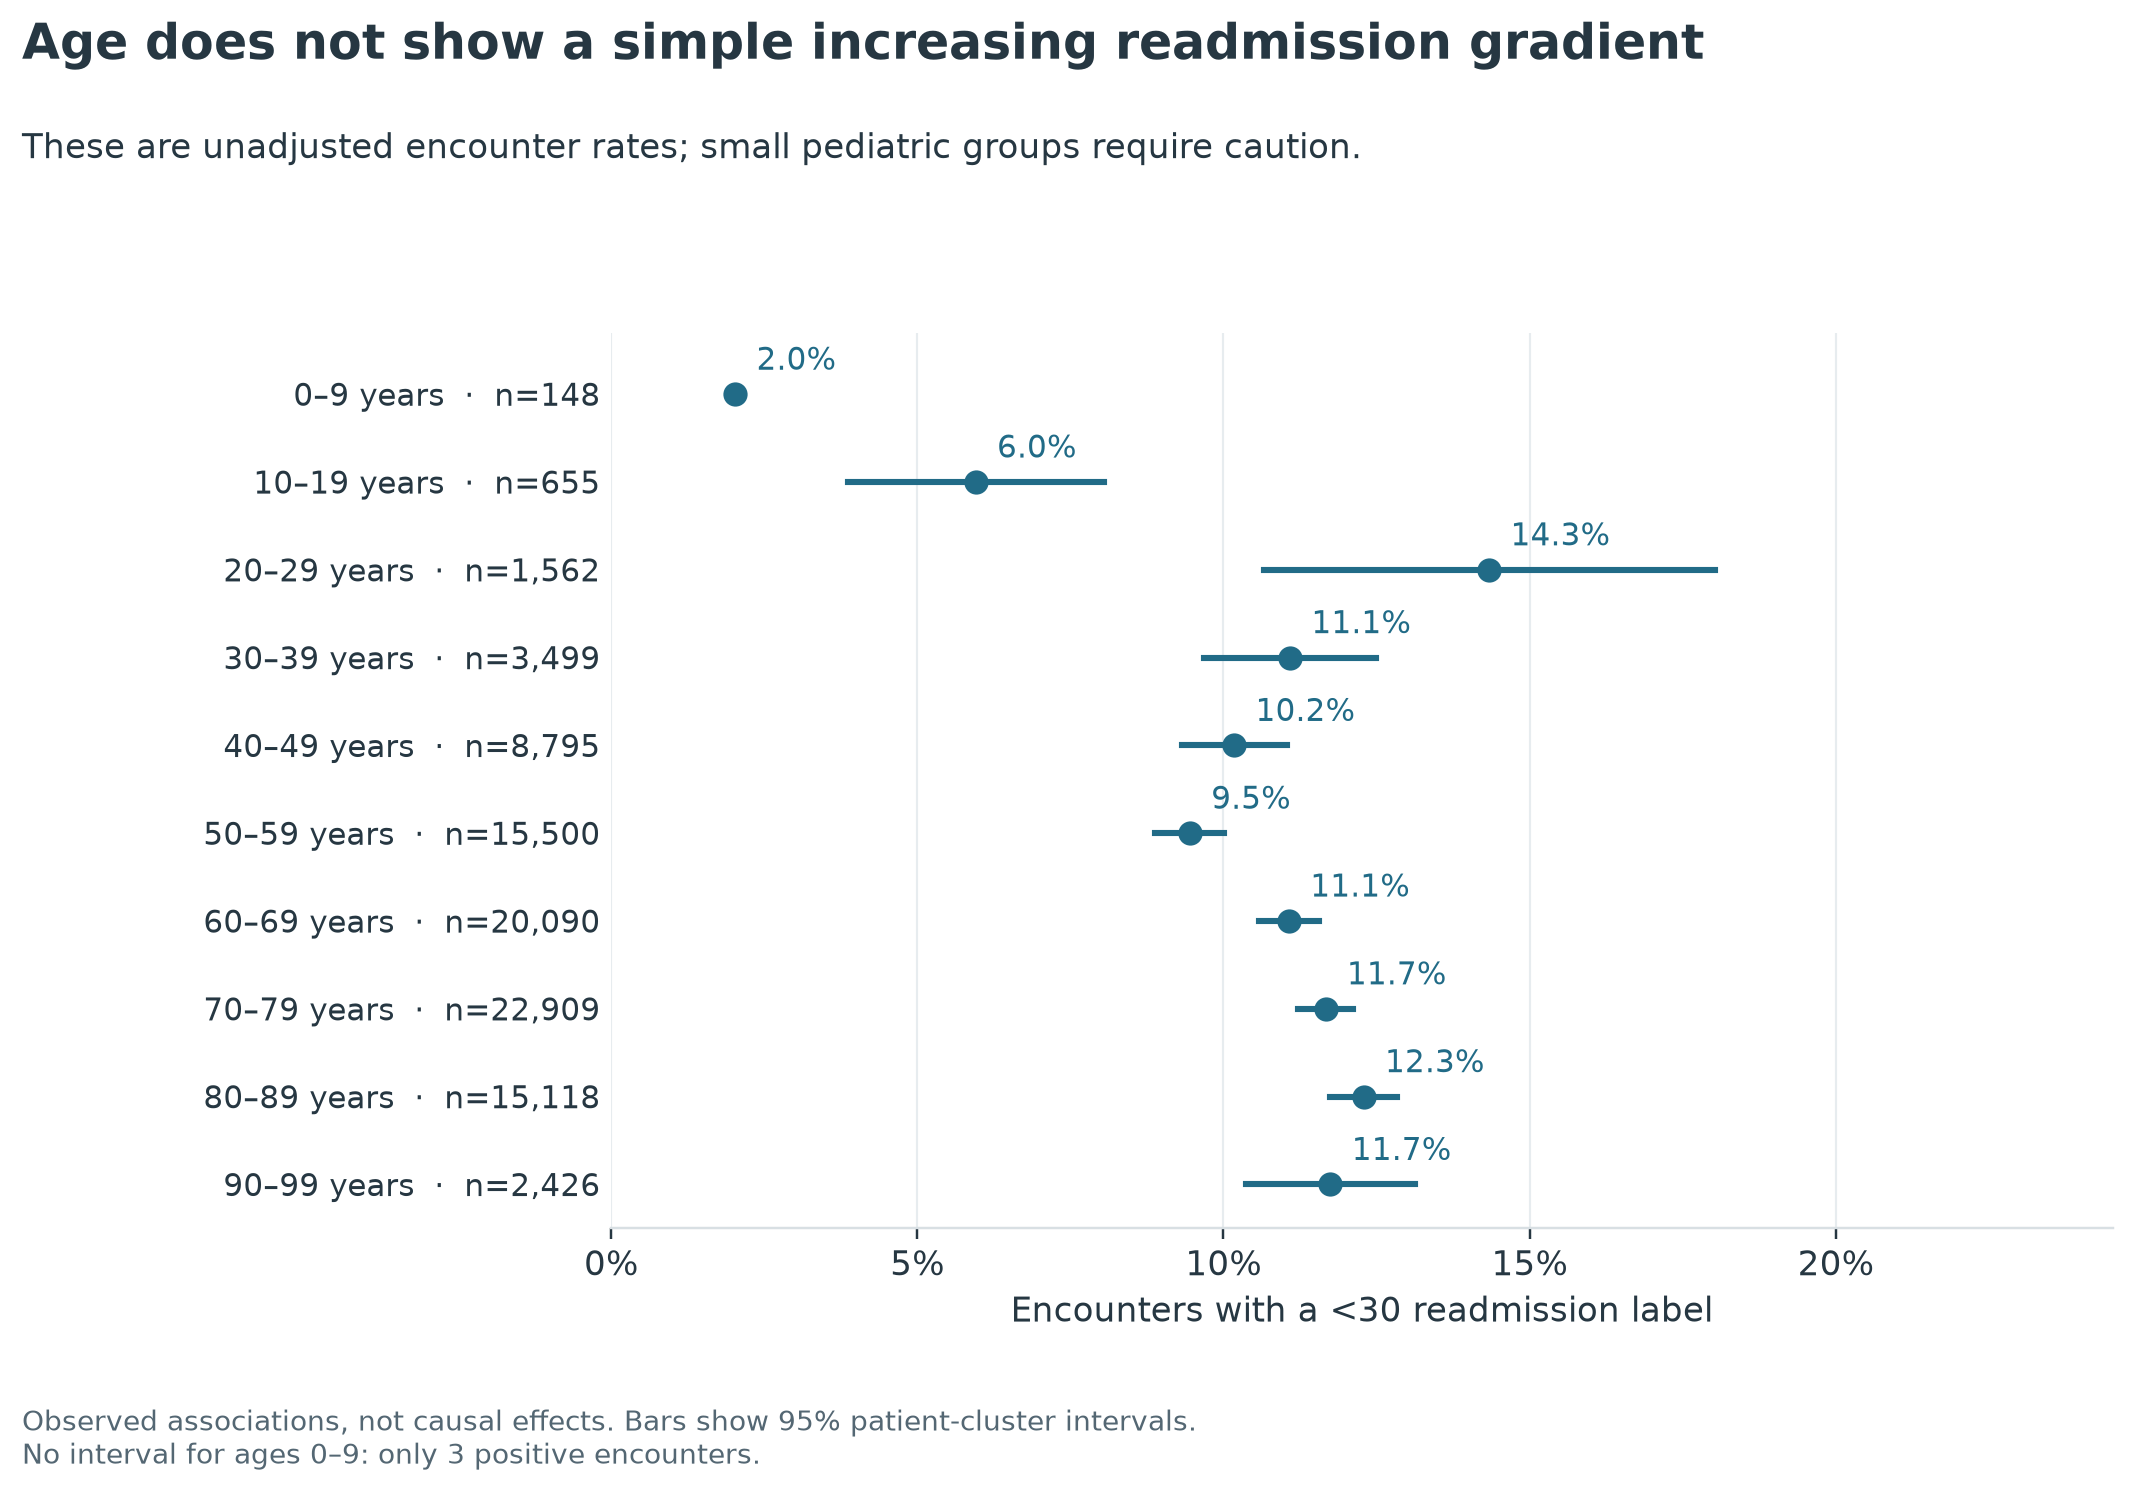

,feature,level,encounters,patients,positives,rate_pct,ci_low_pct,ci_high_pct,sparse
0,gender,Female,48993,34773,5437,11.10,10.76,11.44,False
1,gender,Male,41706,30270,4617,11.07,10.72,11.42,False
2,gender,Unknown/Invalid,3,3,0,0.00,NaN,NaN,True
3,race,AfricanAmerican,17030,11798,1873,11.00,10.43,11.56,False
4,race,Asian,579,474,61,10.54,7.55,13.52,False
5,race,Caucasian,67856,48660,7651,11.28,10.99,11.56,False
6,race,Hispanic,1817,1410,182,10.02,8.44,11.60,False
7,race,Other,1335,1091,121,9.06,7.45,10.67,False
8,race,Unknown,2085,1828,166,7.96,6.72,9.20,False


In [7]:
show_figure('05_age')
show_rates(['gender', 'race'])

### Finding

Age is not a simple increasing relationship. Ages 20–29 have a 14.34% rate
(1,562 encounters), compared with 9.45% at ages 50–59, 11.67% at 70–79 and 12.29% at 80–89.
The youngest band has only three positive encounters; its interval is suppressed.
Female and male marginal rates are nearly identical (**11.10% vs 11.07%**), while the invalid
group has three encounters. Known race-group rates range from about 9.06% to 11.28%; unknown
race has 7.96%. Differences can reflect case mix, access, measurement and selection.

### Modeling implication

Avoid a forced linear age effect. Preserve demographics for subgroup checks and decide their
predictive inclusion through a documented development-only review. Marginal rates do not establish
causality or model fairness; Phase 3 needs subgroup performance and calibration, with uncertainty.

## 7 · Admission and destination describe different care pathways

### Question

Which care settings have different observed rates, and is discharge disposition usable at scoring?

### Analysis

Join admission codes to the historical source mappings. Display destination groups with at least 500 encounters while preserving all groups in the tables.

,level,description,encounters,positives,rate_pct,sparse
0,1,Emergency,48051,5559,11.57,False
1,2,Urgent,16844,1868,11.09,False
2,3,Elective,17109,1681,9.83,False
3,4,Newborn,10,1,10.00,True
4,5,Not Available,4346,462,10.63,False
5,6,NULL,4010,456,11.37,False
6,7,Trauma Center,17,0,0.00,True
7,8,Not Mapped,315,27,8.57,False


,level,description,encounters,positives,rate_pct,sparse
0,1,Physician Referral,26992,2774,10.28,False
1,10,Transfer from critial access hospital,8,0,0.00,True
2,11,Normal Delivery,2,0,0.00,True
3,13,Sick Baby,1,0,0.00,True
4,14,Extramural Birth,2,0,0.00,True
5,17,NULL,5874,609,10.37,False
6,2,Clinic Referral,939,90,9.58,False
7,20,Not Mapped,157,21,13.38,False
8,22,Transfer from hospital inpt/same fac reslt in ...,11,1,9.09,True
9,25,Transfer from Ambulatory Surgery Center,2,0,0.00,True


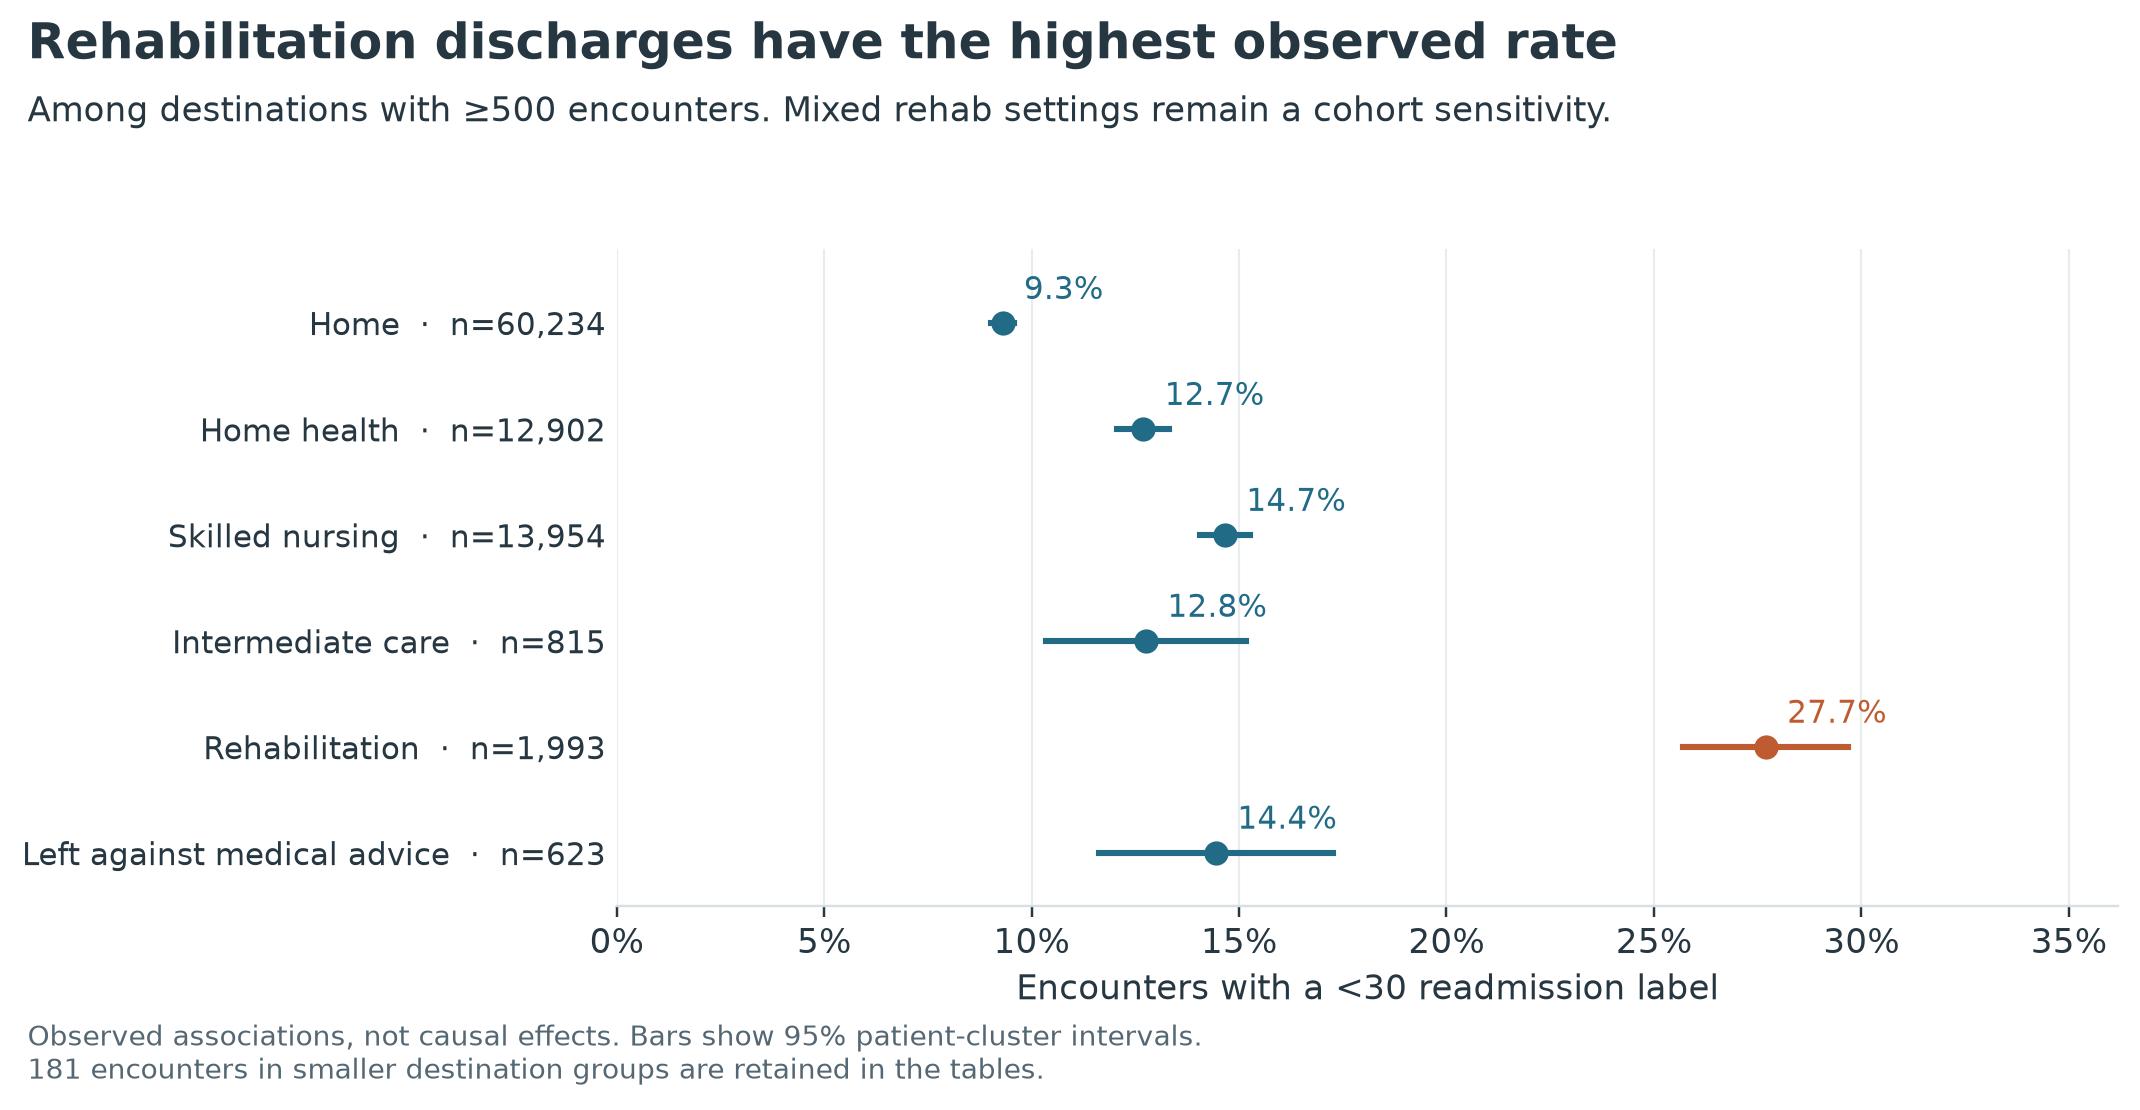

,high_n,low_n,difference_pp,difference_ci_low_pp,difference_ci_high_pp,rate_ratio
rehab_vs_home,1993.0,60234.0,18.397,16.388,20.406,2.978


In [8]:
for feature in ['admission_type_id', 'admission_source_id']:
    view = rates.loc[rates.feature.eq(feature)].copy()
    view['description'] = view.level.astype(int).map(mappings[feature])
    view['rate_pct'] = view.rate.mul(100)
    display(view[['level', 'description', 'encounters', 'positives', 'rate_pct', 'sparse']].round(2).reset_index(drop=True))
show_figure('06_discharge_destination')
show_contrasts(['rehab_vs_home'])

### Finding

Emergency admissions have an 11.57% rate versus 9.83% for elective admissions.
An emergency-room admission source has 11.85%, versus 10.28% for physician referral.
Very small source categories are reported without confident comparisons.

Among destinations with at least 500 encounters, rehabilitation is highest at **27.70%**
(1,993 encounters), versus **9.30%** at home (60,234). The difference is **18.40 pp**
(95% interval 16.39–20.41). Skilled nursing is 14.66% and home health 12.70%.
A further 181 encounters in smaller eligible destinations remain in the analysis tables.

### Modeling implication

Admission codes are categories. Disposition is not automatically leakage when the destination
is confirmed at scoring, but late finalization and a mixed rehabilitation code matter.
Keep it flagged; compare with/without-disposition feature sets on the same frozen cohort.
Do not infer that changing destination reduces readmission. Resolve the intended postacute
workflow before Phase 3, using the cohort sensitivity table.

## 8 · Diagnoses need a clinical mapping, not numeric arithmetic

### Question

Can high-cardinality ICD-9 diagnosis strings be grouped meaningfully without discarding code semantics?

### Analysis

Inspect numeric, short-integer, V and E formats, rare-code coverage and integer-prefix cardinality. Show only the twelve most common primary prefixes; no final clinical transformer is fitted.

In [9]:
inventory = table('diagnosis_inventory')
display(inventory)
prefixes = table('diagnosis_prefixes', dtype={'level': 'string'})
display(prefixes.loc[prefixes.feature.eq('diag_1'), ['level', 'encounters', 'positives', 'rate', 'sparse']].head(12).round(4))

,feature,format,encounters,raw_observed_cardinality,integer_prefix_cardinality,codes_with_under_20_encounters,encounters_in_codes_under_20
0,diag_1,Numeric with three-digit component,87017,708,675,407,2272
1,diag_1,Numeric with short integer component,2288,708,675,407,2272
2,diag_1,V supplementary code,1381,708,675,407,2272
3,diag_1,Unknown,15,708,675,407,2272
4,diag_1,E external-cause code,1,708,675,407,2272
5,diag_2,Numeric with three-digit component,86687,740,707,460,2384
6,diag_2,V supplementary code,1644,740,707,460,2384
7,diag_2,Numeric with short integer component,1360,740,707,460,2384
8,diag_2,E external-cause code,677,740,707,460,2384
9,diag_2,Unknown,334,740,707,460,2384


,level,encounters,positives,rate,sparse
0,250,8043,1040,0.1293,False
1,428,6046,865,0.1431,False
2,414,5661,510,0.0901,False
3,786,3673,251,0.0683,False
4,486,3153,291,0.0923,False
5,410,2769,314,0.1134,False
6,427,2491,231,0.0927,False
7,491,2111,269,0.1274,False
8,715,1931,177,0.0917,False
9,682,1888,168,0.0890,False


### Finding

The eligible cohort has **708 / 740 / 776** observed codes in diag_1/2/3;
**407 / 460 / 496** appear fewer than 20 times. Removing the decimal suffix still leaves
**675 / 707 / 744** observed prefixes, so that operation barely reduces cardinality.
All observed values match inspected numeric, V or E syntax, including short integer components
(e.g. `38`); this is a syntax check, not proof every code is clinically valid.

Primary prefix `250` appears 8,043 times with a 12.93% rate; `428` appears 6,046 times with 14.31%.
These remain source prefixes in this notebook, not hand-labeled clinical groups.
[CDC's ICD-CM definitions](https://www.cdc.gov/nchs/hus/sources-definitions/icd-cm.htm) and
[ICD-9-CM archive](https://archive.cdc.gov/www_cdc_gov/nchs/icd/icd9cm.htm)
provide the starting point for a versioned clinical mapping with numeric and supplementary codes.

### Modeling implication

Broader clinical grouping is a reasonable Phase 3 candidate, but first verify the authoritative
mapping, historical version and coverage. Preserve diagnosis strings and Unknown; explicitly handle
E/V codes, decimals and short integer components. Final billing diagnoses may arrive after scoring;
include a timing-sensitive ablation. Do not encode diagnoses as continuous numbers.

## 9 · Medication indicators warrant a focused follow-up

### Question

Do treatment-change and insulin categories justify deeper analysis?

### Analysis

Inspect only change, diabetesMed and insulin rather than plotting every drug. Keep No prescription distinct from unknown; compare descriptive rates without treatment-effect claims.

In [10]:
show_rates(['change', 'diabetesMed', 'insulin'])

,feature,level,encounters,patients,positives,rate_pct,ci_low_pct,ci_high_pct,sparse
0,change,Ch,42858,32431,5041,11.76,11.40,12.12,False
1,change,No,47844,38246,5013,10.48,10.17,10.78,False
2,diabetesMed,No,20012,17042,1925,9.62,9.17,10.07,False
3,diabetesMed,Yes,70690,51468,8129,11.50,11.22,11.78,False
4,insulin,Down,11195,9006,1562,13.95,13.24,14.67,False
5,insulin,No,41124,33343,4040,9.82,9.51,10.14,False
6,insulin,Steady,28064,23604,3099,11.04,10.65,11.43,False
7,insulin,Up,10319,8359,1353,13.11,12.35,13.88,False


### Finding

Medication-change encounters have an **11.76%** rate versus **10.48%** without change.
Any diabetes medication has **11.50%** versus **9.62%** without. Insulin dose down/up groups have
**13.95% / 13.11%**, steady has **11.04%**, and no insulin **9.82%**.
These are full-stay treatment summaries with likely confounding by indication.

### Modeling implication

Retain these categorical candidates if available by scoring, and test them after the patient split.
Focused medication analysis is warranted, but this phase gives no basis for recommending a dose
change or expanding indiscriminately into every drug interaction. Initially exclude the constant
examide and citoglipton fields from predictors.

## 10 · Establish the boundary for a defensible Phase 3

### Question

Which decisions are settled, and which must be resolved before fitting or evaluating a model?

### Analysis

Review all 50 fields, summarize availability flags and link the explicit preprocessing, feature-discovery and patient-grouped split contracts.

In [11]:
audit = pd.read_csv(ROOT / 'reports/data_quality/feature_audit.csv', keep_default_na=False)
assert len(audit) == 50 and audit.variable.is_unique
assert len(summary['figure_files']) == 7
assert all((FIG / name).exists() for name in summary['figure_files'])
display(audit.groupby('leakage_review').size().rename('fields').to_frame())
display(audit.loc[audit.preliminary_model_exclusion, ['variable', 'treatment']].reset_index(drop=True))
display(pd.Series({'models_trained': summary['models_trained'],
                   'partitions_created': summary['partitions_created'],
                   'figures_saved': len(summary['figure_files']),
                   'raw_source_reconciled': summary['phase1_reconciled']}))

,fields
leakage_review,
definitely safe by source semantics,10
"excluded: constant, not leakage",2
excluded: direct target leakage,1
excluded: identity leakage,2
questionable: billing finalization,1
questionable: discharge snapshot,4
questionable: full-stay reconstruction,23
questionable: result availability,2
questionable: retrospective coding,4


,variable,treatment
0,encounter_id,Keep for audit/grouping only; no ID-order chro...
1,patient_nbr,Keep for audit/grouping only; no ID-order chro...
2,weight,Exclude from first modeling pass; retain for s...
3,examide,Exclude from modeling; keep original field for...
4,citoglipton,Exclude from modeling; keep original field for...
5,readmitted,Outcome only; exclude from every predictor mat...


models_trained               0
partitions_created       False
figures_saved                7
raw_source_reconciled     True
dtype: object

### Finding

The strongest descriptive signals are prior inpatient/emergency utilization, encounter burden
and discharge destination. Outpatient use and age are not simple increasing gradients. No predictive
performance or intervention benefit has been demonstrated.

Identifiers, outcomes and full-dataset future encounter aggregates are excluded from predictors.
Prior-year utilization and admission/demographic information are safe by source semantics, subject
to operational verification. Disposition, finalized diagnoses, labs and full-stay treatment summaries
remain flagged because the extract cannot establish their arrival time.

### Modeling implication

Proceed later with the [cleaning contract](../reports/modeling/cleaning_strategy.md),
[feature discovery plan](../reports/feature_engineering_plan.md),
[50-variable audit](../reports/data_quality/feature_audit.md) and
[patient-grouped 70/15/15 split design](../reports/modeling/split_strategy.md).
Use seed 42 and freeze patient assignments before learning any transformations. Test only a small
set of justified candidates on development data.

**Full-cohort EDA has already examined outcomes.** The future test can remain untouched by fitting
and tuning after it is frozen, but it is not a fully unseen confirmatory dataset. Preserve that
limitation; contemporary external data would strengthen validation. No timestamps or hospital IDs
support temporal or hospital holdouts. Phase 2 stops here: no split, model or fitted preprocessing.